# BaseLine & CNN-LSTM model

In [1]:
import torch
import torch.nn as nn
import sys 
import os
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

# Go to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
csv_path = "../data/doge_2h.csv"
from models.model_class import CNN_LSTM_Model_5 , Base_line_LSTMModel
from models.load_seq import load_sequence_data
from models.metrics import plot_loss_curve, plot_roc_curve, plot_confusion_matrix

## Data Loading and Preprocessing

In [ ]:
FEATURE_COLUMNS = ["open", "high", "low", "close", "volume"]

X, y, X_train, X_test, y_train, y_test = load_sequence_data(csv_path, features=FEATURE_COLUMNS)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(X_train_t.shape, y_train_t.shape)

torch.Size([10471, 48, 5]) torch.Size([10471])


### Dataloader and class imbalance. 

In [ ]:
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)
models_to_test = {
    "Original LSTM": Base_line_LSTMModel(),
    "CNN_LSTM_Model_5": CNN_LSTM_Model_5()
}
# Hyperparameters
EPOCHS = 50
LEARNING_RATE = 0.001 # Increased learning rate for better convergence

In [ ]:
def train_and_evaluate(model_name, model, train_loader, test_loader, X_test_t, y_test):
    """Trains a model, evaluates it, and plots metrics."""
    print(f"\n{'='*50}\n▶️ STARTING TRAINING FOR: {model_name}\n{'='*50}")

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE) 
    
    best_loss = float('inf')
    epoch_losses = [] 

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss_sum = 0 
        
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            outputs = model(Xb).flatten()
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            epoch_loss_sum += loss.item()

        average_epoch_loss = epoch_loss_sum / len(train_loader)
        epoch_losses.append(average_epoch_loss)

        if average_epoch_loss < best_loss:
            best_loss = average_epoch_loss

    print(f"✅ Training Complete for {model_name}. Final best loss: {best_loss:.4f}")

    # --- Evaluation ---
    model.eval()
    y_pred_proba = []
    
    with torch.no_grad():
        for Xb, _ in test_loader:
            outputs = model(Xb).flatten()
            y_pred_proba.extend(outputs.numpy())

    y_pred = (np.array(y_pred_proba) > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    print(f"\n📊 {model_name} Test Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"AUC: {auc:.4f}")

    # --- Visualizations ---
    # The plotting functions use matplotlib and save the images by default
    plot_loss_curve(epoch_losses)
    plot_roc_curve(model, X_test_t, y_test)
    plot_confusion_matrix(model, X_test_t, y_test)
    
    return acc, f1, auc, epoch_losses, np.array(y_pred_proba)


▶️ STARTING TRAINING FOR: Original LSTM
✅ Training Complete for Original LSTM. Final best loss: 0.6928

📊 Original LSTM Test Metrics:
Accuracy: 0.5233
F1: 0.5012
AUC: 0.5249


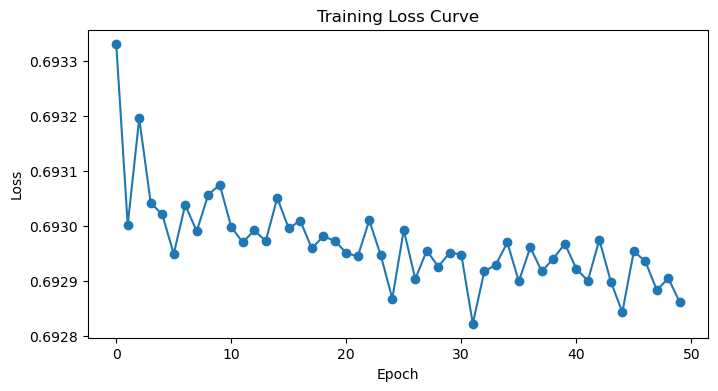

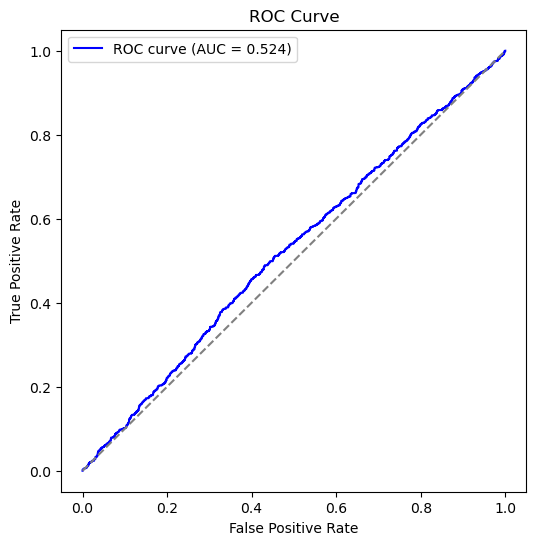

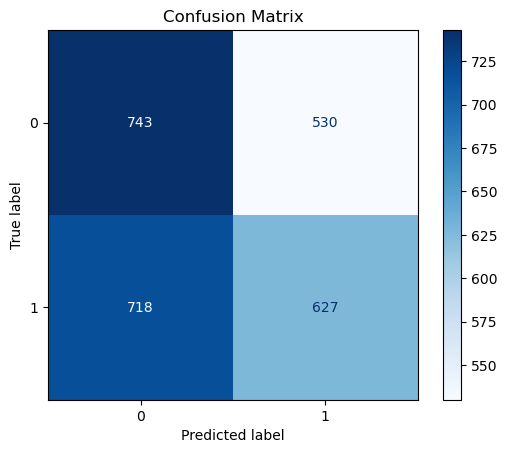


▶️ STARTING TRAINING FOR: CNN_LSTM_Model_5
✅ Training Complete for CNN_LSTM_Model_5. Final best loss: 0.6916

📊 CNN_LSTM_Model_5 Test Metrics:
Accuracy: 0.4969
F1: 0.1794
AUC: 0.5080


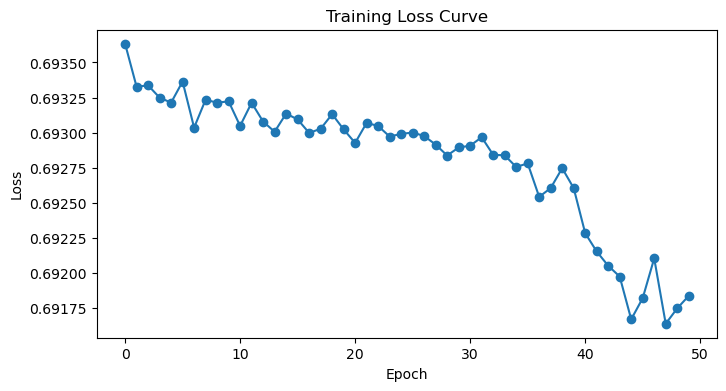

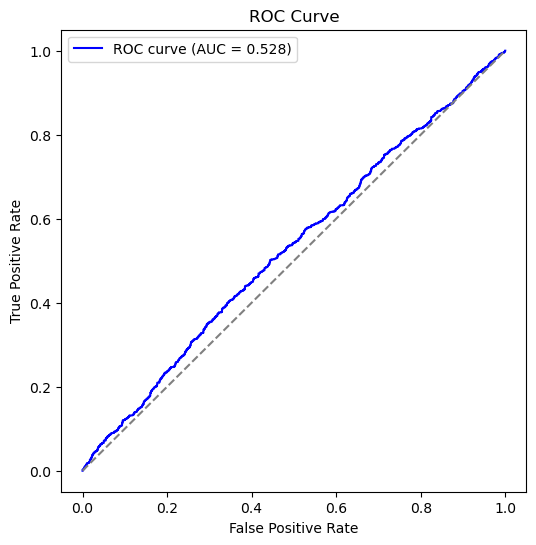

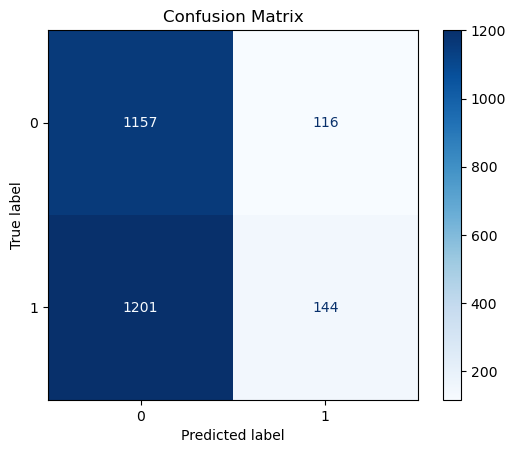

In [5]:
results = {}
loss_histories = {}       # New dictionary for loss curves
proba_predictions = {}    # New dictionary for ROC/Confusion Matrix

for name, model in models_to_test.items():
    # Capture the new return values: losses and probas
    acc, f1, auc, losses, probas = train_and_evaluate(
        name, 
        model, 
        train_loader, 
        test_loader, 
        X_test_t, 
        y_test
    )
    
    results[name] = {'Accuracy': acc, 'F1': f1, 'AUC': auc}
    loss_histories[name] = losses      # Stores {"Model A": [l1, l2, l3...], ...}
    proba_predictions[name] = probas   # Stores {"Model A": [p1, p2, p3...], ...}

In [6]:
import matplotlib.pyplot as plt

def plot_comparison_loss_curve(loss_histories, filename="comparison_loss_curve.png"):
    """Plots the training loss curve for multiple models on the same figure."""
    plt.figure(figsize=(10, 6))
    
    for model_name, losses in loss_histories.items():
        plt.plot(losses, label=model_name)
        
    plt.title('Training Loss Comparison Across Models')
    plt.xlabel('Epoch')
    plt.ylabel('Average BCE Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    # Save the figure if desired: plt.savefig(filename)
    
from sklearn.metrics import roc_curve, auc

def plot_comparison_roc_curve(proba_predictions, y_true, filename="comparison_roc_curve.png"):
    """Plots the ROC curve for multiple models on the same figure."""
    plt.figure(figsize=(8, 8))
    
    for model_name, probas in proba_predictions.items():
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_true, probas)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

    # Plot the random chance line
    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.50)')
    
    plt.title('Receiver Operating Characteristic (ROC) Comparison')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()
    # Save the figure if desired: plt.savefig(filename)
    
from sklearn.metrics import confusion_matrix
import pandas as pd

def print_comparison_confusion_matrix(proba_predictions, y_true):
    """Prints a comparison table of key Confusion Matrix components."""
    
    summary_data = []
    
    for model_name, probas in proba_predictions.items():
        y_pred = (probas > 0.5).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        
        # cm is [[TN, FP], [FN, TP]]
        TN, FP, FN, TP = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
        
        summary_data.append([model_name, TP, FP, TN, FN])

    # Using pandas to print a neat table
    df = pd.DataFrame(summary_data, columns=["Model", "True Positives (TP)", "False Positives (FP)", "True Negatives (TN)", "False Negatives (FN)"])
    
    print("\n\n📊 Confusion Matrix Component Comparison (Threshold=0.5):")
    print(df.to_markdown(index=False)) # Use .to_string() if pandas is not available

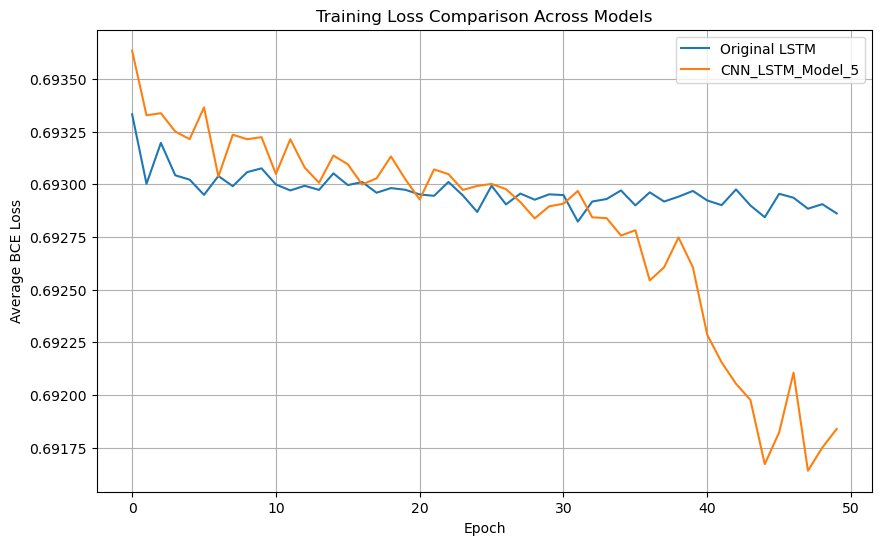

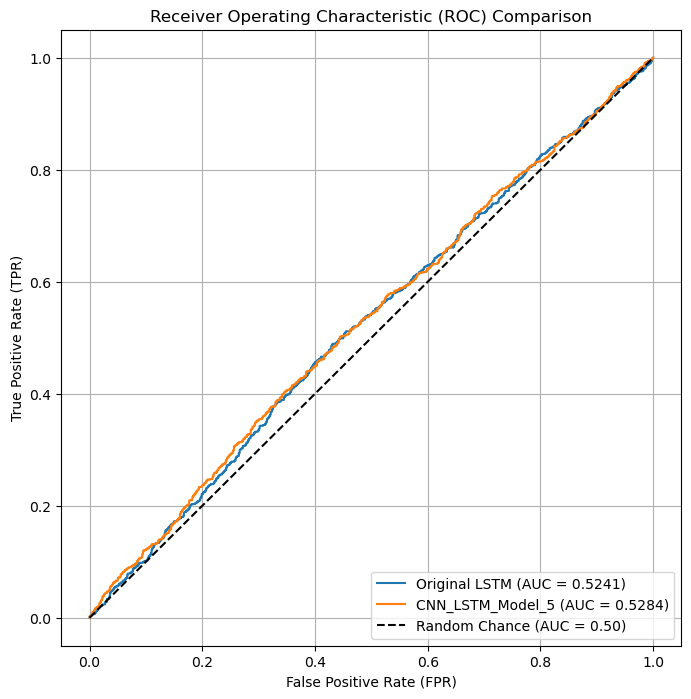



📊 Confusion Matrix Component Comparison (Threshold=0.5):
| Model            |   True Positives (TP) |   False Positives (FP) |   True Negatives (TN) |   False Negatives (FN) |
|:-----------------|----------------------:|-----------------------:|----------------------:|-----------------------:|
| Original LSTM    |                   627 |                    530 |                   743 |                    718 |
| CNN_LSTM_Model_5 |                   144 |                    116 |                  1157 |                   1201 |


In [ ]:

plot_comparison_loss_curve(loss_histories)
plot_comparison_roc_curve(proba_predictions, y_test)
print_comparison_confusion_matrix(proba_predictions, y_test)

In [ ]:
# torch.save(model, "BaseLineModel.pth")
